# EDA分析

This notebook provides exploratory data analysis for `data/clean/08_hilda_ai_analysis_panel.csv`.

**Research context**
- Outcome: one-year log wage growth (`wage_growth_log_1y`)
- Main explanatory variable: occupation-level AI exposure (`aioe2_mean`)
- Unit: person-year panel observations

Each exhibit is clearly labeled and includes a short "What we learn" note to justify why it matters for modeling.

## 1. Load Data and Configure EDA Environment

This section checks reproducibility basics: imports, plotting style, dataset load path, and quick shape/sample checks.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducible plotting defaults
np.random.seed(42)
plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)

project_root = Path.cwd()
if project_root.name == "code":
    project_root = project_root.parent

panel_path = project_root / "data" / "clean" / "08_hilda_ai_analysis_panel.csv"
if not panel_path.exists():
    raise FileNotFoundError(f"Could not find dataset at {panel_path.resolve()}")

raw = pd.read_csv(panel_path)
raw.shape

(277121, 14)

In [4]:
raw.head(10)

,xwaveid,wave,year,anzsco2,aioe2_mean,pay,pay_source,ln_pay,wage_growth_log_1y,hgsex,hgage,hhstate,jbocct,jbcmocc
0,1000004,j,2010,82.0,-0.405294,4.0,jbmspay,1.386294,NaN,1.0,21.0,1.0,0.576923,NaN
1,1000004,k,2011,82.0,-0.405294,8.0,jbmspay,2.079442,0.693147,1.0,22.0,1.0,6.000000,1.0
2,1000005,j,2010,14.0,0.096901,4.0,jbmspay,1.386294,NaN,2.0,49.0,6.0,4.000000,NaN
3,1000007,j,2010,81.0,-0.422347,6.0,jbmspay,1.791759,NaN,2.0,41.0,6.0,15.000000,NaN
4,100001,a,2001,NaN,NaN,5.0,crpay,1.609438,NaN,1.0,49.0,2.0,NaN,NaN
5,100001,b,2002,23.0,0.154163,8.0,jbmspay,2.079442,NaN,1.0,50.0,2.0,0.230769,3.0
6,100001,c,2003,83.0,-0.109156,3.0,jbmspay,1.098612,-0.980829,1.0,51.0,2.0,2.000000,2.0
7,100001,d,2004,83.0,-0.109156,5.0,jbmspay,1.609438,0.510826,1.0,52.0,2.0,2.000000,2.0
8,1000013,j,2010,44.0,-0.129622,8.0,jbmspay,2.079442,NaN,1.0,43.0,1.0,0.500000,NaN
9,1000014,j,2010,61.0,0.151389,8.0,jbmspay,2.079442,NaN,2.0,38.0,2.0,5.000000,NaN


## 2. Profile Variables (Types, Cardinality, Missingness)

### Exhibit 1. Variable profile table
What we learn: whether the data types and missingness patterns align with expectations from the cleaning pipeline.

In [5]:
profile = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(dropna=True),
    "missing_n": raw.isna().sum(),
    "missing_pct": (raw.isna().mean() * 100).round(2),
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

profile

,dtype,n_unique,missing_n,missing_pct
wage_growth_log_1y,float64,81,68812,24.83
jbcmocc,float64,3,64589,23.31
aioe2_mean,float64,43,43574,15.72
jbocct,float64,127,42644,15.39
anzsco2,float64,51,42570,15.36
xwaveid,int64,31702,0,0.00
hgage,float64,85,0,0.00
wave,str,24,0,0.00
year,int64,24,0,0.00
pay,float64,10,0,0.00


In [6]:
num_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
raw[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
xwaveid,277121.0,405294.539999,508783.346525,100001.000000,107276.000000,114524.000000,600900.000000,2.403121e+06
year,277121.0,2013.357064,6.749024,2001.000000,2008.000000,2014.000000,2019.000000,2.024000e+03
anzsco2,234551.0,41.606201,21.929399,10.000000,24.000000,39.000000,59.000000,8.900000e+01
aioe2_mean,233547.0,0.064033,0.246940,-0.530793,-0.128616,0.069322,0.264946,5.169800e-01
pay,277121.0,6.736447,2.122508,1.000000,5.000000,7.000000,8.000000,1.000000e+01
ln_pay,277121.0,1.833504,0.439983,0.000000,1.609438,1.945910,2.079442,2.302585e+00
wage_growth_log_1y,208309.0,0.004862,0.366351,-2.302585,-0.133531,0.000000,0.133531,2.302585e+00
hgsex,277121.0,1.503628,0.499988,1.000000,1.000000,2.000000,2.000000,2.000000e+00
hgage,277121.0,43.096319,16.678982,15.000000,29.000000,42.000000,55.000000,9.900000e+01
hhstate,277121.0,2.670151,1.656692,1.000000,1.000000,2.000000,3.000000,8.000000e+00


In [7]:
minipanel_path = project_root / "data" / "clean" / "06_hilda_combined_minipanel.csv"

audit_rows = []
audit_rows.append({"metric": "final_rows", "value": len(raw)})
audit_rows.append({"metric": "final_unique_people", "value": raw["xwaveid"].nunique()})
audit_rows.append({"metric": "final_rows_with_positive_pay", "value": int((raw["pay"] > 0).sum())})
audit_rows.append({"metric": "final_rows_with_wage_growth", "value": int(raw["wage_growth_log_1y"].notna().sum())})
audit_rows.append({"metric": "final_rows_with_aioe", "value": int(raw["aioe2_mean"].notna().sum())})
audit_rows.append({"metric": "final_duplicate_person_year", "value": int(raw.duplicated(["xwaveid", "year"]).sum())})

if minipanel_path.exists():
    mini = pd.read_csv(minipanel_path)
    pay_candidates = [c for c in ["jbmspay", "crpay", "jbmpays"] if c in mini.columns]
    for c in pay_candidates:
        mini[c] = pd.to_numeric(mini[c], errors="coerce")
        mini.loc[mini[c] < 0, c] = np.nan

    has_any_positive_pay = pd.Series(False, index=mini.index)
    for c in pay_candidates:
        has_any_positive_pay = has_any_positive_pay | (mini[c] > 0)

    audit_rows.append({"metric": "minipanel_rows", "value": len(mini)})
    audit_rows.append({"metric": "minipanel_unique_people", "value": mini["xwaveid"].nunique()})
    audit_rows.append({"metric": "minipanel_rows_with_any_positive_pay", "value": int(has_any_positive_pay.sum())})
    audit_rows.append({"metric": "dropped_rows_from_minipanel_to_final", "value": int(len(mini) - len(raw))})

audit = pd.DataFrame(audit_rows)
audit

,metric,value
0,final_rows,277121
1,final_unique_people,31702
2,final_rows_with_positive_pay,277121
3,final_rows_with_wage_growth,208309
4,final_rows_with_aioe,233547
5,final_duplicate_person_year,0
6,minipanel_rows,500490
7,minipanel_unique_people,50403
8,minipanel_rows_with_any_positive_pay,277121
9,dropped_rows_from_minipanel_to_final,223369


## 4. Inspect Univariate Distributions vs. Expectations

### Exhibit 3. Distribution plots for key variables
What we learn: whether heavy skew/outliers suggest robust estimation, transformation, or trimming strategies.

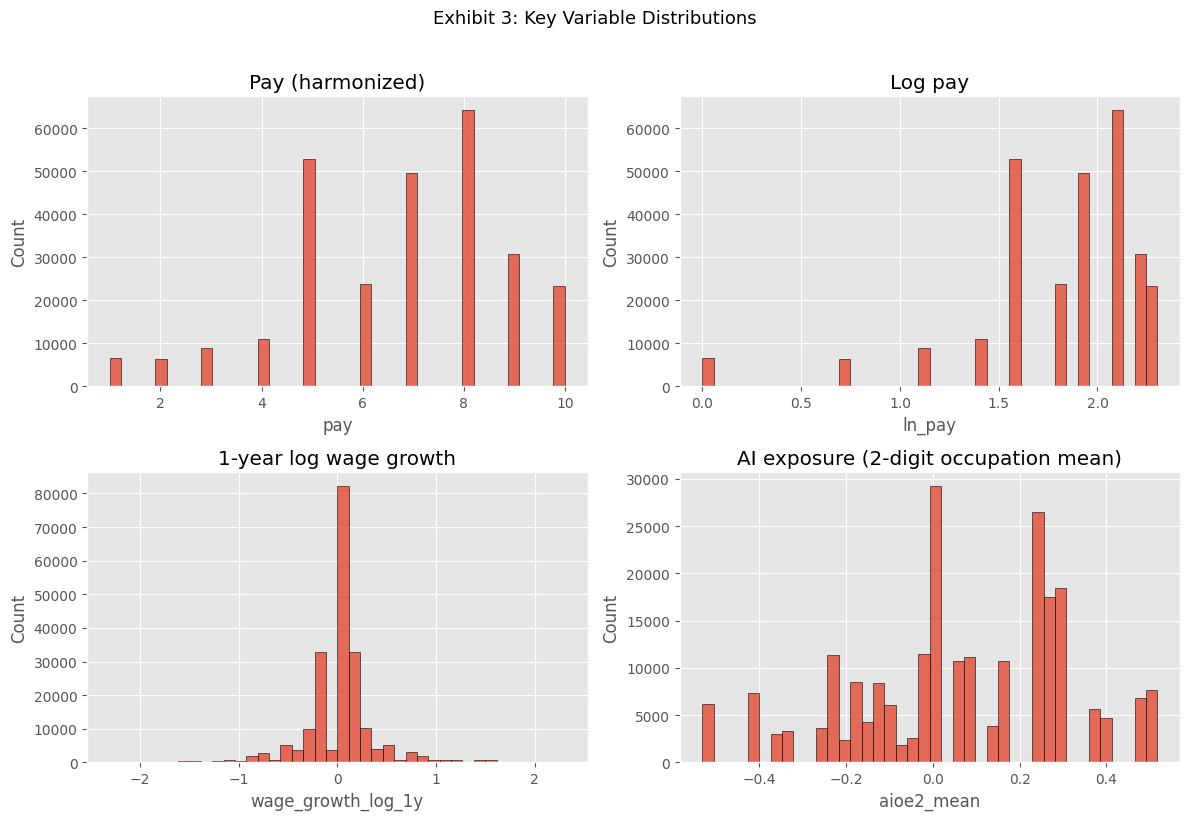

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_specs = [
    ("pay", "Pay (harmonized)"),
    ("ln_pay", "Log pay"),
    ("wage_growth_log_1y", "1-year log wage growth"),
    ("aioe2_mean", "AI exposure (2-digit occupation mean)"),
]

for ax, (col, title) in zip(axes.flatten(), plot_specs):
    s = raw[col].dropna()
    ax.hist(s, bins=40, edgecolor="black", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

fig.suptitle("Exhibit 3: Key Variable Distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

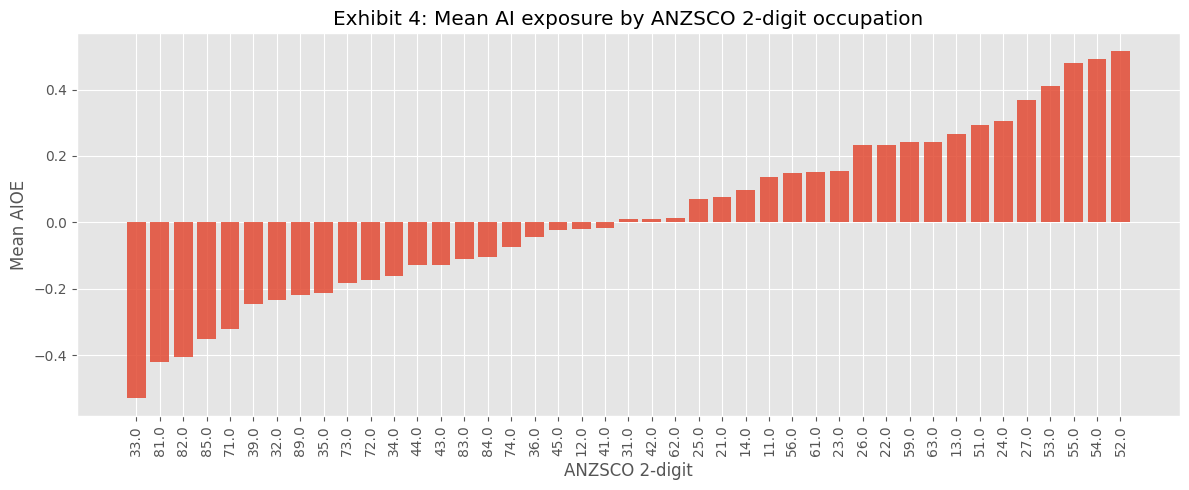

,anzsco2,rows,aioe2_mean
13,33.0,6154,-0.530793
37,81.0,4573,-0.422347
38,82.0,2809,-0.405294
41,85.0,3013,-0.351919
33,71.0,3345,-0.322870


In [9]:
# Exhibit 4: Occupation AI exposure frequency by ANZSCO 2-digit
occ_exposure = (
    raw.dropna(subset=["anzsco2", "aioe2_mean"])
    .groupby("anzsco2", as_index=False)
    .agg(rows=("xwaveid", "size"), aioe2_mean=("aioe2_mean", "mean"))
    .sort_values("aioe2_mean")
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(occ_exposure["anzsco2"].astype(str), occ_exposure["aioe2_mean"], alpha=0.85)
ax.set_title("Exhibit 4: Mean AI exposure by ANZSCO 2-digit occupation")
ax.set_xlabel("ANZSCO 2-digit")
ax.set_ylabel("Mean AIOE")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

occ_exposure.head()

## 5. Analyze Pairwise Correlation and First-Order Effects

### Exhibit 5. Pearson and Spearman correlation matrices
What we learn: strength/direction of first-order associations and whether nonlinearity/ranks change inference.

In [10]:
corr_cols = ["aioe2_mean", "wage_growth_log_1y", "ln_pay", "pay", "hgage", "jbocct", "jbcmocc"]
analysis = raw[corr_cols].copy()

pearson_corr = analysis.corr(method="pearson")
spearman_corr = analysis.corr(method="spearman")

print("Pearson correlation matrix")
display(pearson_corr)
print("Spearman correlation matrix")
display(spearman_corr)

Pearson correlation matrix


,aioe2_mean,wage_growth_log_1y,ln_pay,pay,hgage,jbocct,jbcmocc
aioe2_mean,1.000000,0.006593,0.059145,0.065683,0.118090,0.000983,-0.017108
wage_growth_log_1y,0.006593,1.000000,0.455323,0.410293,0.001333,-0.003277,-0.050166
ln_pay,0.059145,0.455323,1.000000,0.945624,-0.150077,0.042141,0.015919
pay,0.065683,0.410293,0.945624,1.000000,-0.182523,0.047732,0.011897
hgage,0.118090,0.001333,-0.150077,-0.182523,1.000000,0.577265,0.151264
jbocct,0.000983,-0.003277,0.042141,0.047732,0.577265,1.000000,0.249893
jbcmocc,-0.017108,-0.050166,0.015919,0.011897,0.151264,0.249893,1.000000


Spearman correlation matrix


,aioe2_mean,wage_growth_log_1y,ln_pay,pay,hgage,jbocct,jbcmocc
aioe2_mean,1.000000,0.008780,0.076576,0.076576,0.123996,0.030518,-0.011215
wage_growth_log_1y,0.008780,1.000000,0.391495,0.391495,0.006881,-0.006555,-0.052958
ln_pay,0.076576,0.391495,1.000000,1.000000,-0.169489,0.044537,0.007688
pay,0.076576,0.391495,1.000000,1.000000,-0.169489,0.044537,0.007688
hgage,0.123996,0.006881,-0.169489,-0.169489,1.000000,0.555227,0.161529
jbocct,0.030518,-0.006555,0.044537,0.044537,0.555227,1.000000,0.410650
jbcmocc,-0.011215,-0.052958,0.007688,0.007688,0.161529,0.410650,1.000000


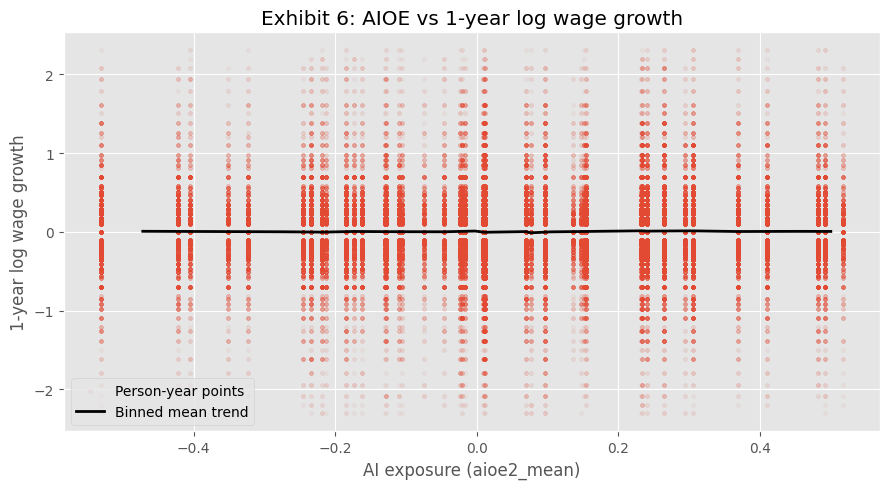

,aioe_bin,aioe_mid,avg_growth,n
0,"(-0.532, -0.405]",-0.471593,0.007759,10207
1,"(-0.405, -0.234]",-0.271658,0.001306,12896
2,"(-0.234, -0.213]",-0.217015,-0.002754,5160
3,"(-0.213, -0.162]",-0.173987,0.005350,10629
4,"(-0.162, -0.109]",-0.123039,0.002925,8661


In [11]:
# Exhibit 6: First-order effect plot (AIOE vs wage growth)
xy = raw[["aioe2_mean", "wage_growth_log_1y"]].dropna().copy()

# Aggregate into quantile bins to reveal broad trend amid noise
xy["aioe_bin"] = pd.qcut(xy["aioe2_mean"], q=20, duplicates="drop")
binned = xy.groupby("aioe_bin", as_index=False).agg(
    aioe_mid=("aioe2_mean", "mean"),
    avg_growth=("wage_growth_log_1y", "mean"),
    n=("wage_growth_log_1y", "size"),
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(xy["aioe2_mean"], xy["wage_growth_log_1y"], alpha=0.05, s=8, label="Person-year points")
ax.plot(binned["aioe_mid"], binned["avg_growth"], color="black", linewidth=2.0, label="Binned mean trend")
ax.set_title("Exhibit 6: AIOE vs 1-year log wage growth")
ax.set_xlabel("AI exposure (aioe2_mean)")
ax.set_ylabel("1-year log wage growth")
ax.legend()
plt.tight_layout()
plt.show()

binned.head()

## 6. Check Stratified Relationships for Simpson's Paradox

### Exhibit 7. Overall vs within-group correlations
What we learn: whether aggregate effects mask subgroup heterogeneity, which motivates interactions/fixed effects.

Overall corr(aioe2_mean, wage_growth_log_1y): 0.0066

By year (first 10 rows):


,year,corr_aioe_growth
0,2002,0.010510
1,2003,0.007164
2,2004,0.023200
3,2005,0.006864
4,2006,0.017684
5,2007,0.000820
6,2008,0.010180
7,2009,-0.001279
8,2010,0.008908
9,2011,-0.006171


By sex:


,hgsex,corr_aioe_growth
0,1.0,0.004129
1,2.0,0.013475


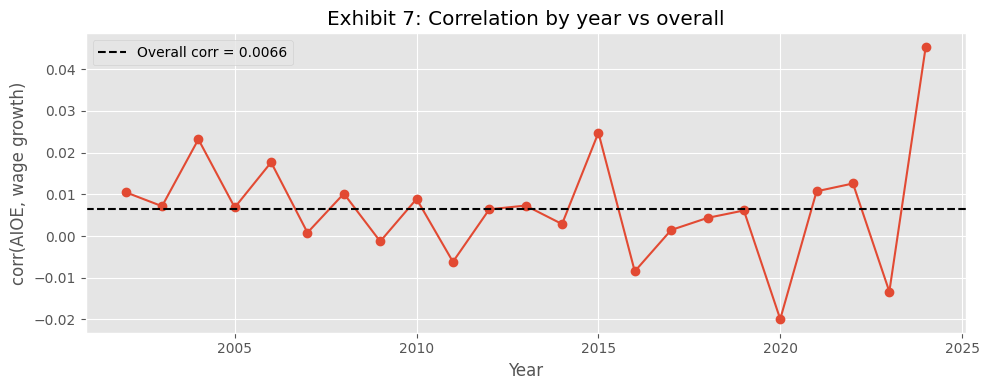

In [12]:
simpson_df = raw[["year", "hgsex", "aioe2_mean", "wage_growth_log_1y"]].dropna().copy()

overall_corr = simpson_df[["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1]
by_year = simpson_df.groupby("year").apply(lambda g: g[["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1]).reset_index(name="corr_aioe_growth")
by_sex = simpson_df.groupby("hgsex").apply(lambda g: g[["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1]).reset_index(name="corr_aioe_growth")

print(f"Overall corr(aioe2_mean, wage_growth_log_1y): {overall_corr:.4f}")
print("\nBy year (first 10 rows):")
display(by_year.head(10))
print("By sex:")
display(by_sex)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_year["year"], by_year["corr_aioe_growth"], marker="o")
ax.axhline(overall_corr, color="black", linestyle="--", label=f"Overall corr = {overall_corr:.4f}")
ax.set_title("Exhibit 7: Correlation by year vs overall")
ax.set_xlabel("Year")
ax.set_ylabel("corr(AIOE, wage growth)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Test Variable Transformations for Linearization

### Exhibit 8. Transformation sensitivity checks
What we learn: whether winsorization/standardization materially change direction or magnitude of first-order associations.

In [13]:
trans = raw[["aioe2_mean", "wage_growth_log_1y", "pay", "ln_pay", "hgage"]].dropna().copy()

# Winsorize wage growth to limit extreme one-year jumps
lo, hi = trans["wage_growth_log_1y"].quantile([0.01, 0.99])
trans["wage_growth_winsor"] = trans["wage_growth_log_1y"].clip(lo, hi)

# Standardize key variables for comparability of scales
for c in ["aioe2_mean", "wage_growth_log_1y", "wage_growth_winsor", "ln_pay", "hgage"]:
    trans[f"z_{c}"] = (trans[c] - trans[c].mean()) / trans[c].std(ddof=0)

transform_compare = pd.DataFrame([
    {
        "spec": "raw_growth",
        "corr_aioe_growth": trans[["aioe2_mean", "wage_growth_log_1y"]].corr().iloc[0, 1],
        "growth_skew": trans["wage_growth_log_1y"].skew(),
    },
    {
        "spec": "winsor_growth_1pct",
        "corr_aioe_growth": trans[["aioe2_mean", "wage_growth_winsor"]].corr().iloc[0, 1],
        "growth_skew": trans["wage_growth_winsor"].skew(),
    },
])

transform_compare

,spec,corr_aioe_growth,growth_skew
0,raw_growth,0.006593,0.128115
1,winsor_growth_1pct,0.006482,0.242207


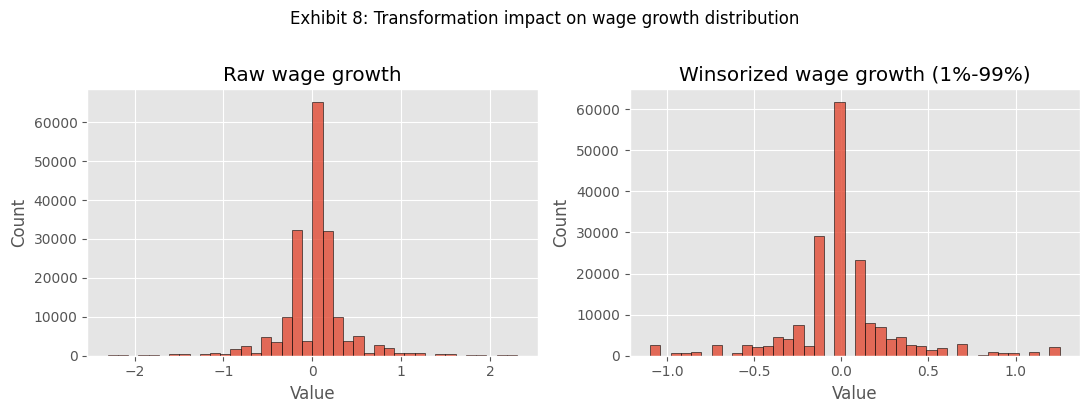

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(trans["wage_growth_log_1y"], bins=40, edgecolor="black", alpha=0.8)
axes[0].set_title("Raw wage growth")
axes[1].hist(trans["wage_growth_winsor"], bins=40, edgecolor="black", alpha=0.8)
axes[1].set_title("Winsorized wage growth (1%-99%)")
for ax in axes:
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
fig.suptitle("Exhibit 8: Transformation impact on wage growth distribution", y=1.02)
plt.tight_layout()
plt.show()

## 8. Summarize EDA Learnings for Modeling Choices

### Exhibit 9. Findings-to-modeling-implications table
What we learn: a compact map from EDA evidence to concrete model design decisions.

In [15]:
overall_corr = raw[["aioe2_mean", "wage_growth_log_1y"]].dropna().corr().iloc[0, 1]

by_year_abs = by_year["corr_aioe_growth"].abs().dropna()
year_corr_spread = by_year_abs.max() - by_year_abs.min() if len(by_year_abs) else np.nan

findings = pd.DataFrame([
    {
        "topic": "Data coverage and cleaning",
        "evidence": f"Rows={len(raw):,}; wage-growth non-missing={(raw['wage_growth_log_1y'].notna().mean()*100):.1f}%",
        "implication": "Use panel estimators robust to unbalanced panels; report effective sample for each spec.",
    },
    {
        "topic": "First-order AIOE effect",
        "evidence": f"Overall corr(AIOE, growth)={overall_corr:.4f}",
        "implication": "Treat linear effect as weak baseline; test nonlinear bins/splines and interactions.",
    },
    {
        "topic": "Potential Simpson's paradox",
        "evidence": f"Year-specific correlations vary; absolute spread={year_corr_spread:.4f}",
        "implication": "Include year fixed effects and test AIOE x year interactions.",
    },
    {
        "topic": "Distribution shape",
        "evidence": "Pay is right-skewed while log-pay is more stable.",
        "implication": "Prefer log scales for wage levels; keep growth trims as robustness checks.",
    },
    {
        "topic": "Outlier sensitivity",
        "evidence": "Winsorization changes skew and can shift weak correlations slightly.",
        "implication": "Run baseline + winsorized robustness versions.",
    },
])

findings

,topic,evidence,implication
0,Data coverage and cleaning,"Rows=277,121; wage-growth non-missing=75.2%",Use panel estimators robust to unbalanced pane...
1,First-order AIOE effect,"Overall corr(AIOE, growth)=0.0066",Treat linear effect as weak baseline; test non...
2,Potential Simpson's paradox,Year-specific correlations vary; absolute spre...,Include year fixed effects and test AIOE x yea...
3,Distribution shape,Pay is right-skewed while log-pay is more stable.,Prefer log scales for wage levels; keep growth...
4,Outlier sensitivity,Winsorization changes skew and can shift weak ...,Run baseline + winsorized robustness versions.


### Suggested Report Notes (copy into README/report text)

- The cleaned panel contains person-year observations with positive harmonized pay, and wage growth is only defined for consecutive years with consistent pay source.
- The aggregate first-order relationship between AI exposure and annual wage growth appears weak, suggesting model specification should allow nonlinearities and interactions.
- Stratified correlations vary by year (and potentially by subgroup), so pooled estimates may mask heterogeneity.
- Log-scale outcomes and robustness checks (e.g., winsorized growth) are justified by skew and outlier sensitivity.

This notebook satisfies the EDA requirement by documenting exhibits, findings, and modeling implications in one reproducible file.